# Naive Bayes Classifier

### Overview

For each step, read the explanation, then **run the code cell(s)** right below it.

You will practice how to:

- Load and prepare data for a Naive Bayes classification problem
- Split the data into training and validation sets
- Compute exact and conditional probabilities manually using cross-tab summaries to provide a conceptual understanding of Naive Bayes
- Fit a `MultinomialNB` model and compare to the manual probability calculations
- Discuss the intuition between the difference in probabilities

#### Import libraries

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed variable for code reproducibility
SEED = 1

### Personal Loan Example

**Create a dataframe for the `UniversalBank.csv` data**

In the next cell, we load the dataset from a `.csv` file into a pandas DataFrame so we can explore it and prepare it for Naive Bayes modeling.

For this tutorial, we only keep these three variables:

* `Online`
* `CreditCard`
* `Personal_Loan`

Be sure to maintain the full dataset for additional analysis.

This is the Personal Loan Acceptance example in the lecture.

In [2]:
cols = ['Online', 'CreditCard', 'Personal_Loan']

bank_all_df = pd.read_csv(os.path.join('..', 'data', 'UniversalBank.csv'))
bank_all_df.columns = [c.replace(' ', '_') for c in bank_all_df.columns]
bank_df = bank_all_df[cols]

bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Online         5000 non-null   int64
 1   CreditCard     5000 non-null   int64
 2   Personal_Loan  5000 non-null   int64
dtypes: int64(3)
memory usage: 117.3 KB


In [3]:
bank_df.head()

,Online,CreditCard,Personal_Loan
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,1,0


**Split dataset into training and validation sets**

Next, we partition the data into a **training set (60%)** and a **validation set (40%)**.

We will use the training set to calculate probabilities and fit the Naive Bayes model. 


In [4]:
train_df, valid_df = train_test_split(bank_df, test_size=0.4, random_state=SEED)

print('Training Set:', train_df.shape)
print('Validation Set:', valid_df.shape)

Training Set: (3000, 3)
Validation Set: (2000, 3)


**Create a frequency table for `CreditCard`, `Online`, and `Personal_Loan`**

Now we create a crosstab using:

- `CreditCard` and `Online` as the row variables, and
- `Personal_Loan` as the column variable.

This gives us the exact counts for each combination in the training data.


In [5]:
ct = pd.crosstab(
    index=[train_df['CreditCard'], train_df['Online']],
    columns=train_df['Personal_Loan']
)

ct

Personal_Loan         0    1
CreditCard Online           
0          0        792   73
           1       1117  126
1          0        327   39
           1        477   49

**Use the frequency table to calculate the exact probability**

Suppose a customer:

* has a bank credit card (`CreditCard = 1`), and
* actively uses online banking (`Online = 1`)

Using the crosstab counts, we can directly estimate:

\begin{flalign*}
& P(\text{Loan}=1 \mid \text{CreditCard}=1, \text{Online}=1) &&
\end{flalign*}

This uses the observed frequency for that exact combination.


In [6]:
p_loan1 = ct.loc[(1, 1), 1]
p_loan0 = ct.loc[(1, 1), 0]

exact_prob = p_loan1 / (p_loan0 + p_loan1)
print(f"Exact probability for P(Loan = 1 | CreditCard = 1, Online = 1) = {exact_prob:.4f}")

Exact probability for P(Loan = 1 | CreditCard = 1, Online = 1) = 0.0932


**Create the prior and conditional probability tables**

To apply Naive Bayes manually, we need:

The **prior probabilities**:

\begin{flalign*}
& P(\text{Loan}=1) && \\
& P(\text{Loan}=0) &&
\end{flalign*}

The **conditional probabilities**:

\begin{flalign*}
& P(\text{CreditCard}=1 \mid \text{Loan}=1) && \\
& P(\text{Online}=1 \mid \text{Loan}=1) && \\
& P(\text{CreditCard}=1 \mid \text{Loan}=0) && \\
& P(\text{Online}=1 \mid \text{Loan}=0) &&
\end{flalign*}

The next cells compute these pieces step by step.


In [7]:
loan_prior = train_df['Personal_Loan'].value_counts(normalize=True).sort_index()

lp0 = loan_prior[0]
lp1 = loan_prior[1]

print(f"Prior probability for P(Loan = 0) = {lp0:.4f}")
print(f"Prior probability for P(Loan = 1) = {lp1:.4f}")

Prior probability for P(Loan = 0) = 0.9043
Prior probability for P(Loan = 1) = 0.0957


In [8]:
cc_n = pd.crosstab(
    index=train_df['CreditCard'],
    columns=train_df['Personal_Loan'],
    normalize='columns'
)

cc_n

Personal_Loan,0,1
CreditCard,,
0,0.703649,0.69338
1,0.296351,0.30662


In [9]:
ol_n = pd.crosstab(
    index=train_df['Online'],
    columns=train_df['Personal_Loan'],
    normalize='columns'
)

ol_n

Personal_Loan,0,1
Online,,
0,0.412459,0.390244
1,0.587541,0.609756


**Identify the key probabilities needed for Naive Bayes**

From the tables above, the quantities we need are:

\begin{flalign*}
& P(\text{CreditCard}=1 \mid \text{Loan}=1) && \\
& P(\text{Online}=1 \mid \text{Loan}=1) && \\
& P(\text{Loan}=0) && \\
& P(\text{CreditCard}=1 \mid \text{Loan}=0) && \\
& P(\text{Online}=1 \mid \text{Loan}=0) &&
\end{flalign*}


In [10]:
print(f"P(Loan = 1) = {lp1:.4f}")
print(f"P(CreditCard = 1 | Loan = 1) = {cc_n.loc[1, 1]:.4f}")
print(f"P(Online = 1 | Loan = 1) = {ol_n.loc[1, 1]:.4f}")
print("----------------------------------------------------")
print(f"P(Loan = 0) = {lp0:.4f}")
print(f"P(CreditCard = 1 | Loan = 0) = {cc_n.loc[1, 0]:.4f}")
print(f"P(Online = 1 | Loan = 0) = {ol_n.loc[1, 0]:.4f}")

P(Loan = 1) = 0.0957
P(CreditCard = 1 | Loan = 1) = 0.3066
P(Online = 1 | Loan = 1) = 0.6098
----------------------------------------------------
P(Loan = 0) = 0.9043
P(CreditCard = 1 | Loan = 0) = 0.2964
P(Online = 1 | Loan = 0) = 0.5875


**Compute the Naive Bayes probability manually**

Naive Bayes assumes the predictors are conditionally independent given the class.

So for a customer with `CreditCard = 1` and `Online = 1`, we estimate:

\begin{flalign*}
& P(\text{Loan}=1 \mid \text{CreditCard}=1,\text{Online}=1) &&
\end{flalign*}

using

\begin{flalign*}
& \frac{
P(\text{Loan}=1)\,P(\text{CreditCard}=1\mid\text{Loan}=1)\,P(\text{Online}=1\mid\text{Loan}=1)
}{
P(\text{Loan}=1)\,P(\text{CreditCard}=1\mid\text{Loan}=1)\,P(\text{Online}=1\mid\text{Loan}=1)
+
P(\text{Loan}=0)\,P(\text{CreditCard}=1\mid\text{Loan}=0)\,P(\text{Online}=1\mid\text{Loan}=0)
} &&
\end{flalign*}

In [11]:
num_loan1 = lp1 * cc_n.loc[1, 1] * ol_n.loc[1, 1]
num_loan0 = lp0 * cc_n.loc[1, 0] * ol_n.loc[1, 0]

nb_manual_prob = num_loan1 / (num_loan1 + num_loan0)
print(f"Naive Bayes probability P(Loan = 1 | CreditCard = 1, Online = 1) = {nb_manual_prob:.4f}")

Naive Bayes probability P(Loan = 1 | CreditCard = 1, Online = 1) = 0.1020


**Compare the exact probability to the Naive Bayes probability**

The exact probability uses the direct frequency counts for the combination:

* `CreditCard = 1`
* `Online = 1`

The Naive Bayes probability is usually a little different because it assumes:

* `CreditCard` and `Online` are **independent given the loan class**.

That simplifying assumption makes Naive Bayes efficient, especially when there are many predictors, but it can introduce some approximation error.


In [12]:
comparison = pd.Series({
    'Exact probability': exact_prob,
    'Manual Naive Bayes probability': nb_manual_prob,
    'Difference': exact_prob - nb_manual_prob
})

comparison

Exact probability                 0.093156
Manual Naive Bayes probability    0.102004
Difference                       -0.008848
dtype: float64

**Prepare the predictors for scikit-learn Naive Bayes**

To fit a `MultinomialNB` model in scikit-learn, we will:

1. convert the predictor columns to `category`,
2. one-hot encode the predictors, and
3. fit the model on the training data.

This step lets us confirm the probability using the actual Naive Bayes classifier implementation.


In [13]:
train_df_nb = train_df.copy()

train_df_nb[cols[:2]] = train_df_nb[cols[:2]].astype('category')
train_df_nb = pd.get_dummies(train_df_nb, prefix_sep='_')
train_df_nb['Personal_Loan'] = train_df_nb['Personal_Loan'].astype('category')

train_df_nb.head()

,Personal_Loan,Online_0,Online_1,CreditCard_0,CreditCard_1
4522,0,True,False,True,False
2851,0,False,True,True,False
2313,0,False,True,False,True
982,0,True,False,False,True
1164,1,False,True,True,False


In [14]:
predictors = ['Online_0', 'Online_1', 'CreditCard_0', 'CreditCard_1']

nb = MultinomialNB(alpha=0.01)
nb.fit(train_df_nb[predictors], train_df_nb['Personal_Loan'])

MultinomialNB(alpha=0.01)

**Predict probabilities from the fitted Naive Bayes model**

Next, we generate predicted probabilities for all rows in the training set.

Then we isolate the rows where:

* `Online = 1`
* `CreditCard = 1`

and inspect the predicted probability for `Personal_Loan = 1`.


In [15]:
pred_prob = nb.predict_proba(train_df_nb[predictors])

predicted = pd.concat(
    [train_df_nb, pd.DataFrame(pred_prob, index=train_df_nb.index, columns=nb.classes_)],
    axis=1
)

matches = (predicted['Online_1'] == 1) & (predicted['CreditCard_1'] == 1)
predicted[matches].head()

,Personal_Loan,Online_0,Online_1,CreditCard_0,CreditCard_1,0,1
2313,0,False,True,False,True,0.897993,0.102007
1918,1,False,True,False,True,0.897993,0.102007
4506,0,False,True,False,True,0.897993,0.102007
586,0,False,True,False,True,0.897993,0.102007
3591,0,False,True,False,True,0.897993,0.102007


**Extract the model-based probability for `Loan = 1` when `Online = 1` and `CreditCard = 1`**

Because all rows with the same dummy-variable pattern receive the same Naive Bayes prediction, we can read the predicted probability for class `1` from any matching row.


In [16]:
model_prob = predicted.loc[matches, 1].iloc[0]

print(f"MultinomialNB probability P(Loan = 1 | CreditCard = 1, Online = 1) = {model_prob:.4f}")

MultinomialNB probability P(Loan = 1 | CreditCard = 1, Online = 1) = 0.1020


**Discuss differences in probability estimates**

The **frequency based estimate** is usually the more accurate estimate for this very small two-predictor setup because it uses the exact observed frequency for the combination `CreditCard = 1` and `Online = 1`.

The **Naive Bayes estimate** can differ slightly because it makes the simplifying assumption that:

* `CreditCard` and `Online` are conditionally independent given `Personal_Loan`.

That assumption is often helpful in larger problems because it reduces complexity and allows the model to estimate probabilities even when many predictor combinations are sparse or rarely observed.


### Checking the Independence Assumption

In practice, the independence assumption is often violated, but Naive Bayes can still perform well if the predictors are **only weakly correlated**.

One simple way to explore whether two binary predictors are related is to compute their **Pearson correlation coefficient**. Finally, compute the correlation between all binary variables in the full bank dataset:

* `Securities_Account`
* `CD_Account`
* `Online`
* `CreditCard`
  
and `Personal_Loan`


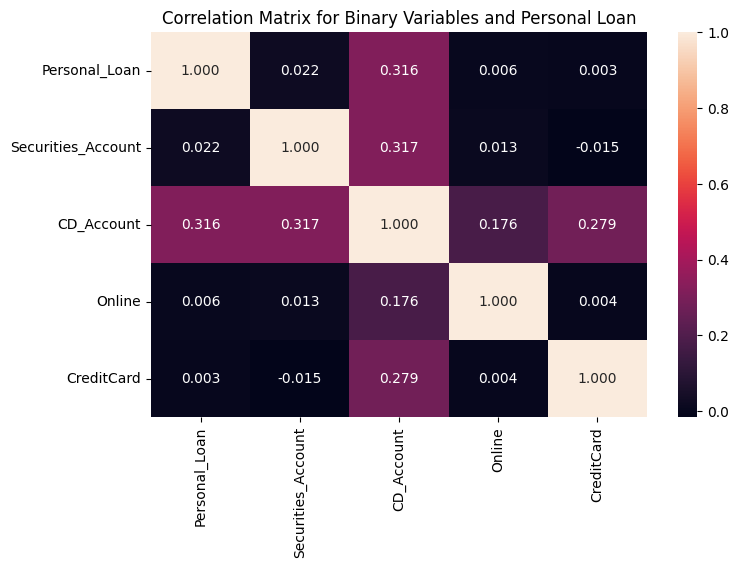

In [17]:
corr_cols = ['Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']
bank_corr = bank_all_df[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(bank_corr, annot=True, fmt='.3f', ax=ax)
plt.title('Correlation Matrix for Binary Variables and Personal Loan')
plt.show()

If the correlation is closer to zero, it suggests that the two variables are relatively independent. This helps explain why the difference between the exact probability calculation and the Naive Bayes probability for `CreditCard` and `Online` was relatively small.

### Key MultinomialNB Parameters

Below are a few important parameters for the `MultinomialNB` classifier.

**`alpha`**  
Controls smoothing.

* A small positive value prevents zero probabilities.
* Larger values apply more smoothing.
* In this tutorial, we used `alpha=0.01`.

**`fit_prior`**  
Determines whether the model learns class prior probabilities from the training data.

* `True` → learn priors from the data (default)
* `False` → use uniform class priors unless `class_prior` is supplied

**`class_prior`**  
Lets you manually specify the prior probabilities for each class instead of estimating them from the data.

This is useful when you want to override the sample proportions with known business or domain knowledge.
